<a href="https://colab.research.google.com/github/hieutran121197/python-data-science-final/blob/main/SpaceX_Capstone_Assets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpaceX Capstone - assets (data export, web scraping, Folium maps, Dash dashboard)

In [1]:
!pip install -q dash folium playwright
!playwright install --with-deps chromium > /dev/null 2>&1 && echo chromium-ok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 MB 14.2 MB/s eta 0:00:00
chromium-ok


In [2]:
import pandas as pd
B = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/"
files = {'dataset_part_1.csv': B+'datasets/dataset_part_1.csv',
         'dataset_part_2.csv': B+'datasets/dataset_part_2.csv',
         'dataset_part_3.csv': B+'datasets/dataset_part_3.csv',
         'Spacex.csv': B+'labs/module_2/data/Spacex.csv',
         'spacex_launch_geo.csv': B+'datasets/spacex_launch_geo.csv',
         'spacex_launch_dash.csv': B+'datasets/spacex_launch_dash.csv'}
dfs = {k: pd.read_csv(v) for k, v in files.items()}
for k, d in dfs.items():
    print('=====FILE', k)
    print(d.to_csv(index=False))
    print('=====END')

=====FILE dataset_part_1.csv
FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
1,2010-06-04,Falcon 9,6104.959411764706,LEO,CCAFS SLC 40,None None,1,False,False,False,,1.0,0,B0003,-80.577366,28.5618571
2,2012-05-22,Falcon 9,525.0,LEO,CCAFS SLC 40,None None,1,False,False,False,,1.0,0,B0005,-80.577366,28.5618571
3,2013-03-01,Falcon 9,677.0,ISS,CCAFS SLC 40,None None,1,False,False,False,,1.0,0,B0007,-80.577366,28.5618571
4,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,,1.0,0,B1003,-120.610829,34.632093
5,2013-12-03,Falcon 9,3170.0,GTO,CCAFS SLC 40,None None,1,False,False,False,,1.0,0,B1004,-80.577366,28.5618571
6,2014-01-06,Falcon 9,3325.0,GTO,CCAFS SLC 40,None None,1,False,False,False,,1.0,0,B1005,-80.577366,28.5618571
7,2014-04-18,Falcon 9,2296.0,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,,1.0,0,B1006,-80.577366,28.5618571
8,2014-07-14,Falcon 9,1316.0,LEO

## Web scraping - Falcon 9 launch records (Wikipedia snapshot 9 June 2021)

In [3]:
import requests, re
from bs4 import BeautifulSoup
static_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"
resp = requests.get(static_url, headers={'User-Agent': 'Mozilla/5.0 (capstone lab)'})
print('status', resp.status_code)
soup = BeautifulSoup(resp.text, 'html.parser')
print(soup.title)

def clean(el):
    return re.sub(r'\[\d+\]', '', el.get_text(' ', strip=True)).replace('\xa0', ' ').strip()

cols = ['Flight No.', 'Date', 'Time', 'Version Booster', 'Launch site', 'Payload', 'Payload mass',
        'Orbit', 'Customer', 'Launch outcome', 'Booster landing']
launch_dict = {c: [] for c in cols}
tables = soup.find_all('table', 'wikitable plainrowheaders collapsible')
print('launch tables:', len(tables))
for table in tables:
    for tr in table.find_all('tr'):
        th = tr.th
        if not (th and th.string and th.string.strip().isdigit()):
            continue
        td = tr.find_all('td')
        if len(td) < 9:
            continue
        dt = clean(td[0]).split()
        launch_dict['Flight No.'].append(th.string.strip())
        launch_dict['Date'].append(' '.join(dt[:3]).strip(','))
        launch_dict['Time'].append(dt[3] if len(dt) > 3 else '')
        launch_dict['Version Booster'].append(clean(td[1]))
        launch_dict['Launch site'].append(clean(td[2]))
        launch_dict['Payload'].append(clean(td[3]))
        m = re.search(r'([\d,\.]+)\s*kg', clean(td[4]))
        launch_dict['Payload mass'].append(m.group(1) + ' kg' if m else '0')
        launch_dict['Orbit'].append(clean(td[5]))
        launch_dict['Customer'].append(clean(td[6]))
        launch_dict['Launch outcome'].append(clean(td[7]))
        launch_dict['Booster landing'].append(clean(td[8]))
scraped = pd.DataFrame(launch_dict)
print('SCRAPED_SHAPE', scraped.shape)
print('=====FILE spacex_web_scraped.csv')
print(scraped.to_csv(index=False))
print('=====END')

status 200
<title>List of Falcon 9 and Falcon Heavy launches - Wikipedia</title>
launch tables: 9
SCRAPED_SHAPE (121, 11)
=====FILE spacex_web_scraped.csv
Flight No.,Date,Time,Version Booster,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Booster landing
1,4 June 2010,18:45,F9 v1.0 [ 7 ] B0003.1 [ 8 ],"CCAFS , SLC-40",Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure [ 9 ] [ 10 ] (parachute)
2,8 December 2010,15:43,F9 v1.0 [ 7 ] B0004.1 [ 8 ],"CCAFS , SLC-40",Dragon demo flight C1 (Dragon C101),0,LEO ( ISS ),NASA ( COTS ) NRO,Success [ 9 ],Failure [ 9 ] [ 14 ] (parachute)
3,22 May 2012,07:44,F9 v1.0 [ 7 ] B0005.1 [ 8 ],"CCAFS , SLC-40",Dragon demo flight C2+ [ 18 ] (Dragon C102),525 kg,LEO ( ISS ),NASA ( COTS ),Success [ 20 ],No attempt
4,8 October 2012,00:35,F9 v1.0 [ 7 ] B0006.1 [ 8 ],"CCAFS , SLC-40",SpaceX CRS-1 [ 22 ] (Dragon C103),"4,700 kg",LEO ( ISS ),NASA ( CRS ),Success,No attempt
5,1 March 2013,15:10,F9 v1.0 [ 7 ] B0007.1 [ 8 ],"CCAFS , SLC-40

## Folium maps

In [4]:
import folium
from folium.plugins import MarkerCluster, MousePosition
from folium.features import DivIcon
from math import sin, cos, sqrt, atan2, radians
geo = dfs['spacex_launch_geo.csv']
TILES = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}'
sites = geo.groupby('Launch Site', as_index=False).first()[['Launch Site', 'Lat', 'Long']]
print(sites)

m1 = folium.Map(location=[31.0, -99], zoom_start=5, tiles=TILES, attr='Esri')
for _, r in sites.iterrows():
    folium.Circle([r.Lat, r.Long], radius=20000, color='#d35400', fill=True, fill_opacity=0.3).add_to(m1)
    folium.Marker([r.Lat, r.Long], icon=DivIcon(icon_size=(170, 20), icon_anchor=(-8, 10),
        html=f'<div style="font-size:14px;font-weight:bold;color:#d35400;white-space:nowrap">{r["Launch Site"]}</div>')).add_to(m1)
m1.save('map1_sites.html')

def outcome_map(center, zoom, name):
    m = folium.Map(location=center, zoom_start=zoom, tiles=TILES, attr='Esri')
    mc = MarkerCluster().add_to(m)
    for _, r in geo.iterrows():
        c = 'green' if r['class'] == 1 else 'red'
        folium.Marker([r.Lat, r.Long], icon=folium.Icon(color='white', icon_color=c)).add_to(mc)
    m.save(name)
outcome_map([31.0, -99], 5, 'map2_clusters.html')
outcome_map([28.573255, -80.646895], 18, 'map2_ksc.html')

def dist(a, b):
    R = 6373.0
    la1, lo1, la2, lo2 = map(radians, [a[0], a[1], b[0], b[1]])
    x = sin((la2-la1)/2)**2 + cos(la1)*cos(la2)*sin((lo2-lo1)/2)**2
    return R * 2 * atan2(sqrt(x), sqrt(1-x))
site = (28.56319718, -80.57682003)
points = {'Coastline': (28.56342, -80.56794), 'Highway': (28.56335, -80.57085),
          'Railway': (28.57206, -80.58526), 'City (Titusville)': (28.61200, -80.80788)}
m3 = folium.Map(location=[28.585, -80.68], zoom_start=12, tiles=TILES, attr='Esri')
folium.Marker(site, icon=folium.Icon(color='blue')).add_to(m3)
folium.Marker(site, icon=DivIcon(icon_size=(160, 20), icon_anchor=(-12, 30),
    html='<div style="font-size:13px;font-weight:bold;color:#1f4e9c;white-space:nowrap">CCAFS SLC-40</div>')).add_to(m3)
prox = []
for name, p in points.items():
    d = dist(site, p); prox.append((name, round(d, 2)))
    folium.PolyLine([site, p], weight=3, color='#c0392b').add_to(m3)
    folium.Marker(p, icon=DivIcon(icon_size=(220, 20), icon_anchor=(0, 0),
        html=f'<div style="font-size:12px;font-weight:bold;color:#c0392b;background:white;padding:1px 4px;white-space:nowrap">{name}: {d:.2f} km</div>')).add_to(m3)
m3.save('map3_prox.html')
print('PROXIMITY', prox)

    Launch Site        Lat        Long
0   CCAFS LC-40  28.562302  -80.577356
1  CCAFS SLC-40  28.563197  -80.576820
2    KSC LC-39A  28.573255  -80.646895
3   VAFB SLC-4E  34.632834 -120.610745
PROXIMITY [('Coastline', 0.87), ('Highway', 0.58), ('Railway', 1.29), ('City (Titusville)', 23.21)]


## Plotly Dash dashboard

In [5]:
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
import plotly.express as px
sdf = dfs['spacex_launch_dash.csv']
max_p, min_p = sdf['Payload Mass (kg)'].max(), sdf['Payload Mass (kg)'].min()
app = dash.Dash(__name__)
opts = [{'label': 'All Sites', 'value': 'ALL'}] + [{'label': s, 'value': s} for s in sdf['Launch Site'].unique()]
app.layout = html.Div([
    html.H1('SpaceX Launch Records Dashboard', style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
    dcc.Dropdown(id='site-dropdown', options=opts, value='ALL', placeholder='Select a Launch Site here', searchable=True),
    html.Br(),
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),
    html.P('Payload range (Kg):'),
    dcc.RangeSlider(id='payload-slider', min=0, max=10000, step=1000,
                    marks={i: str(i) for i in range(0, 10001, 2500)}, value=[min_p, max_p]),
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

@app.callback(Output('success-pie-chart', 'figure'), Input('site-dropdown', 'value'))
def pie(site):
    if site == 'ALL':
        return px.pie(sdf[sdf['class'] == 1], names='Launch Site', title='Total Successful Launches by Site')
    d = sdf[sdf['Launch Site'] == site]['class'].value_counts().reset_index()
    d.columns = ['class', 'count']
    d['Outcome'] = d['class'].map({1: 'Success', 0: 'Failure'})
    return px.pie(d, values='count', names='Outcome', title=f'Total Success vs. Failure Launches for {site}')

@app.callback(Output('success-payload-scatter-chart', 'figure'),
              [Input('site-dropdown', 'value'), Input('payload-slider', 'value')])
def scatter(site, pr):
    d = sdf[(sdf['Payload Mass (kg)'] >= pr[0]) & (sdf['Payload Mass (kg)'] <= pr[1])]
    t = f'Correlation between Payload and Success for All Sites ({pr[0]:,.0f} - {pr[1]:,.0f} kg)'
    if site != 'ALL':
        d = d[d['Launch Site'] == site]; t = f'Correlation between Payload and Success for {site}'
    return px.scatter(d, x='Payload Mass (kg)', y='class', color='Booster Version Category', title=t)

app.run(jupyter_mode='external', port=8050)

Dash app running on:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

## Screenshots (headless Chromium)

In [10]:
script = r"""
from playwright.sync_api import sync_playwright
def key(d, idx, keys):
    t = d.locator('#payload-slider [role=slider]').nth(idx)
    t.focus()
    for k in keys:
        d.keyboard.press(k); d.wait_for_timeout(150)
    d.wait_for_timeout(4000)
with sync_playwright() as p:
    b = p.chromium.launch()
    d = b.new_page(viewport={'width': 1280, 'height': 1050})
    d.goto('http://127.0.0.1:8050'); d.wait_for_timeout(8000)
    print('slider thumbs:', d.locator('#payload-slider [role=slider]').count())
    key(d, 1, ['End'] + ['ArrowLeft'] * 5)
    d.screenshot(path='dash_low.png', full_page=True)
    key(d, 1, ['End'])
    key(d, 0, ['Home'] + ['ArrowRight'] * 5)
    d.screenshot(path='dash_high.png', full_page=True)
    b.close()
print('done')
"""
open('shots2.py', 'w').write(script)
!timeout 120 python shots2.py
!ls -la *.png

slider thumbs: 2
done
-rw-r--r-- 1 root root   72565 Sep 26 04:31 dash_all.png
-rw-r--r-- 1 root root   70522 Sep 26 04:34 dash_high.png
-rw-r--r-- 1 root root   66335 Sep 26 04:32 dash_ksc.png
-rw-r--r-- 1 root root   73269 Sep 26 04:34 dash_low.png
-rw-r--r-- 1 root root 1308100 Sep 26 04:28 map1_sites.png
-rw-r--r-- 1 root root 1305891 Sep 26 04:28 map2_clusters.png
-rw-r--r-- 1 root root  295675 Sep 26 04:28 map2_ksc.png
-rw-r--r-- 1 root root  969129 Sep 26 04:29 map3_prox.png


=====IMG map1_sites


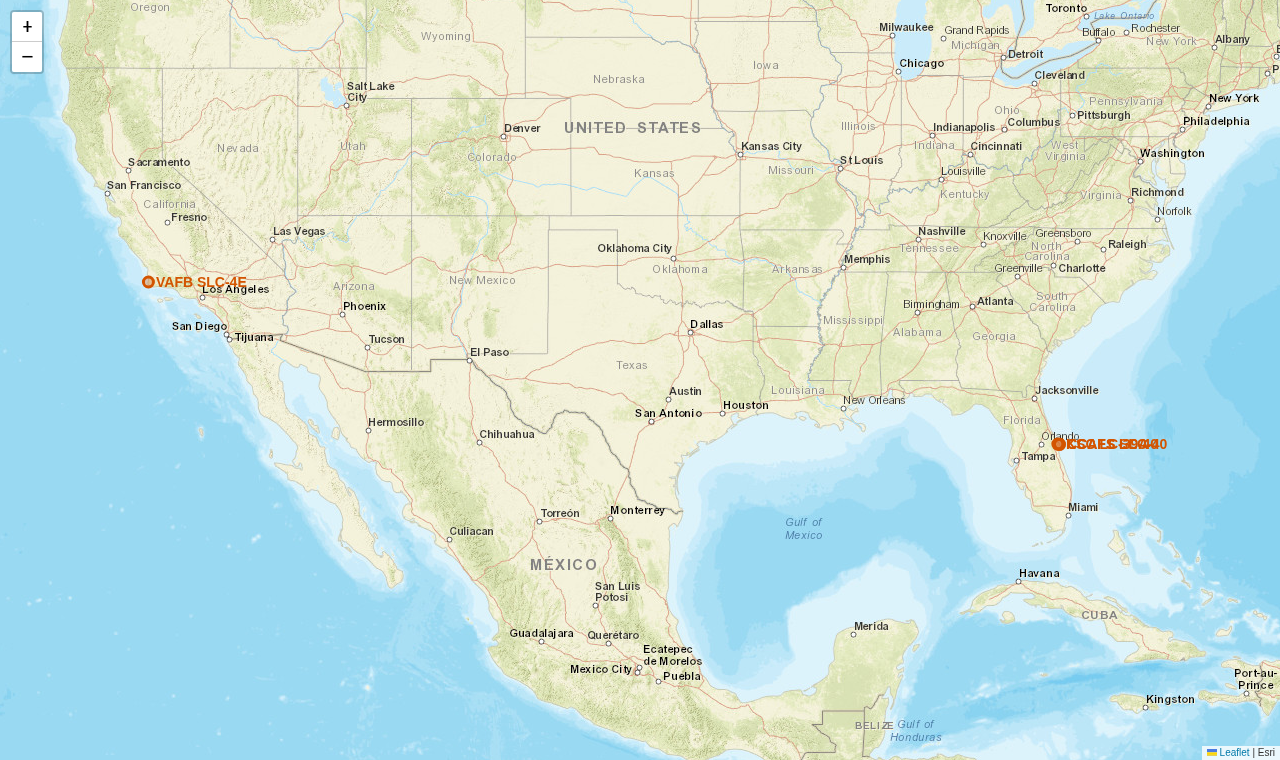

=====IMG map2_clusters


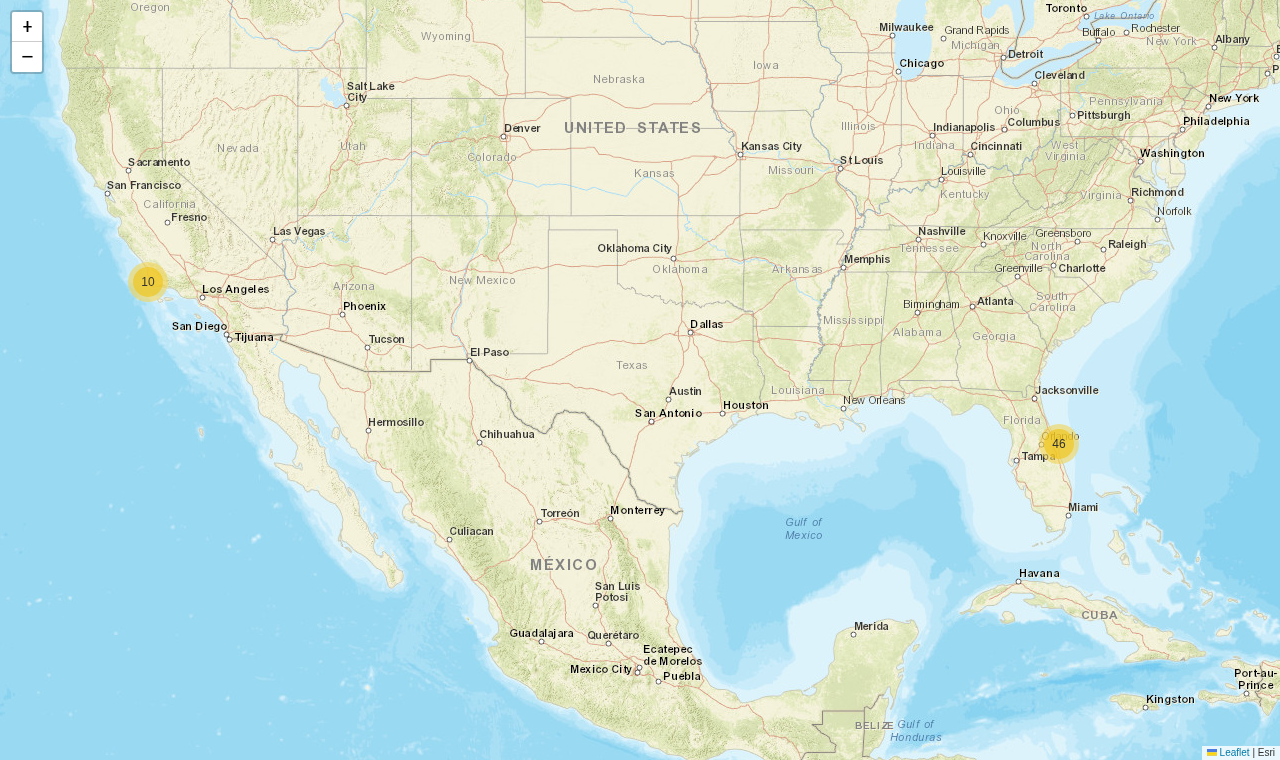

=====IMG map2_ksc


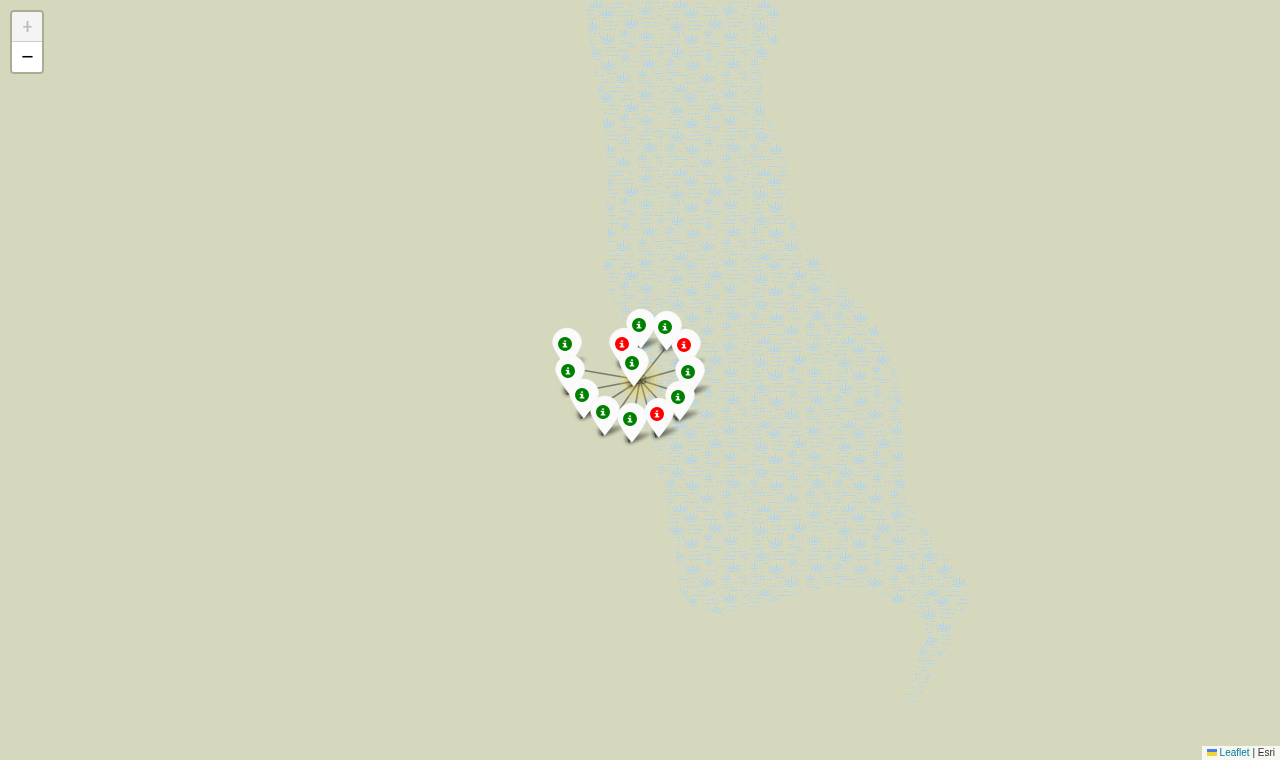

=====IMG map3_prox


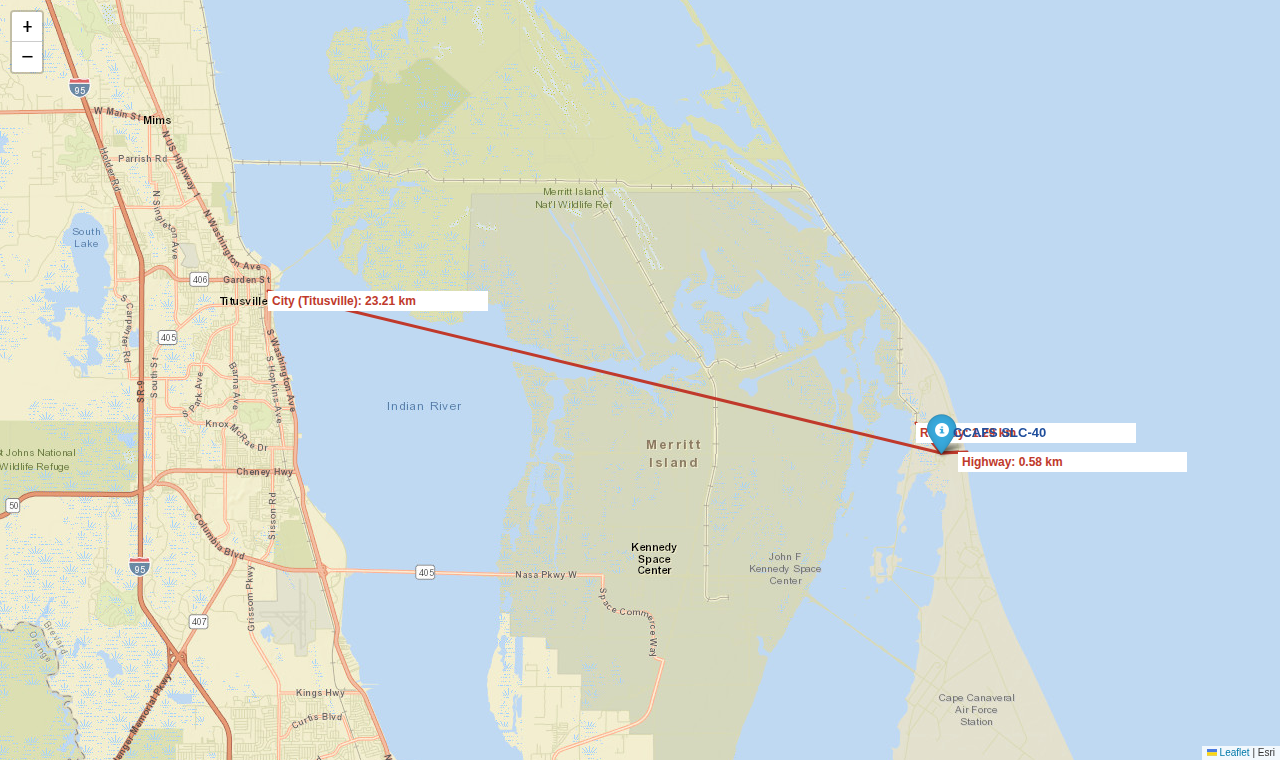

=====IMG dash_all


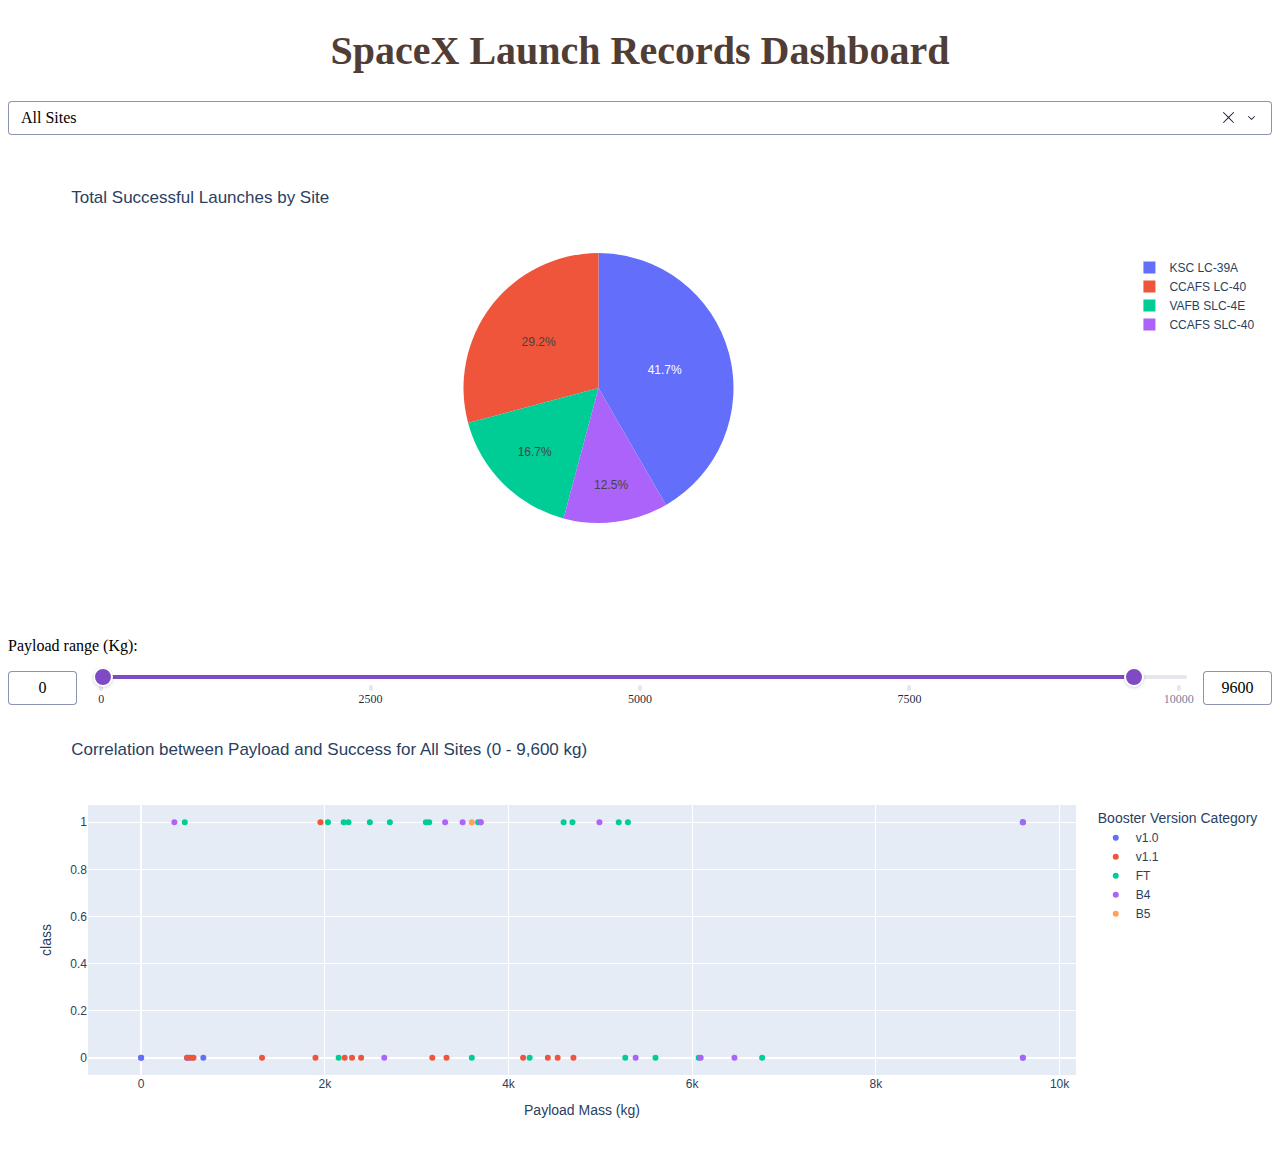

=====IMG dash_ksc


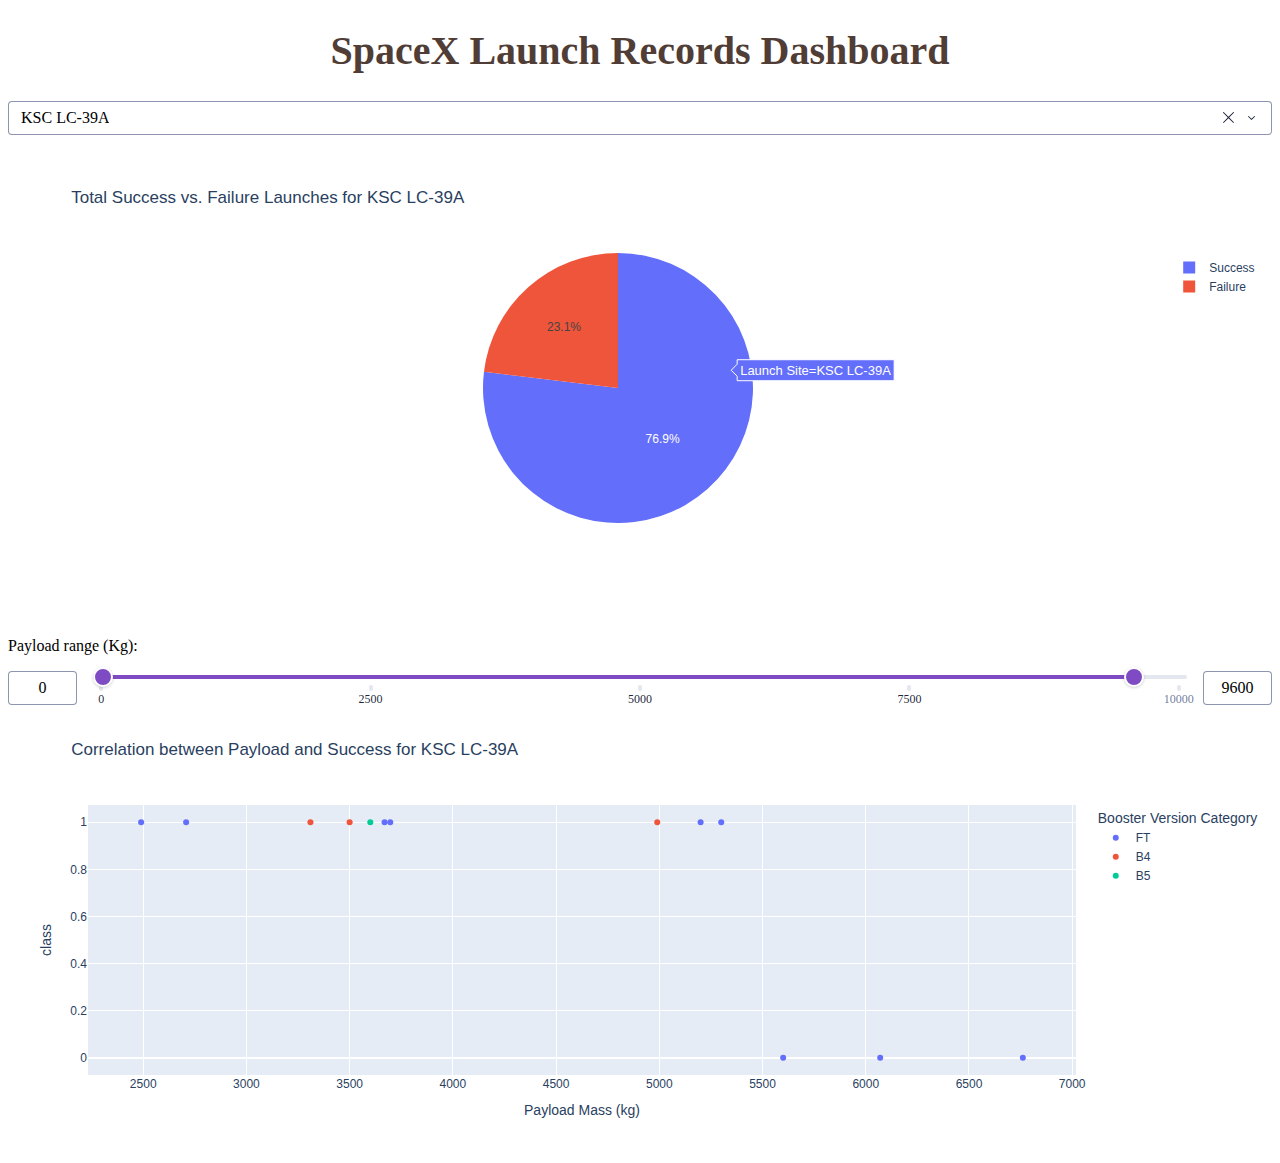

=====IMG dash_low


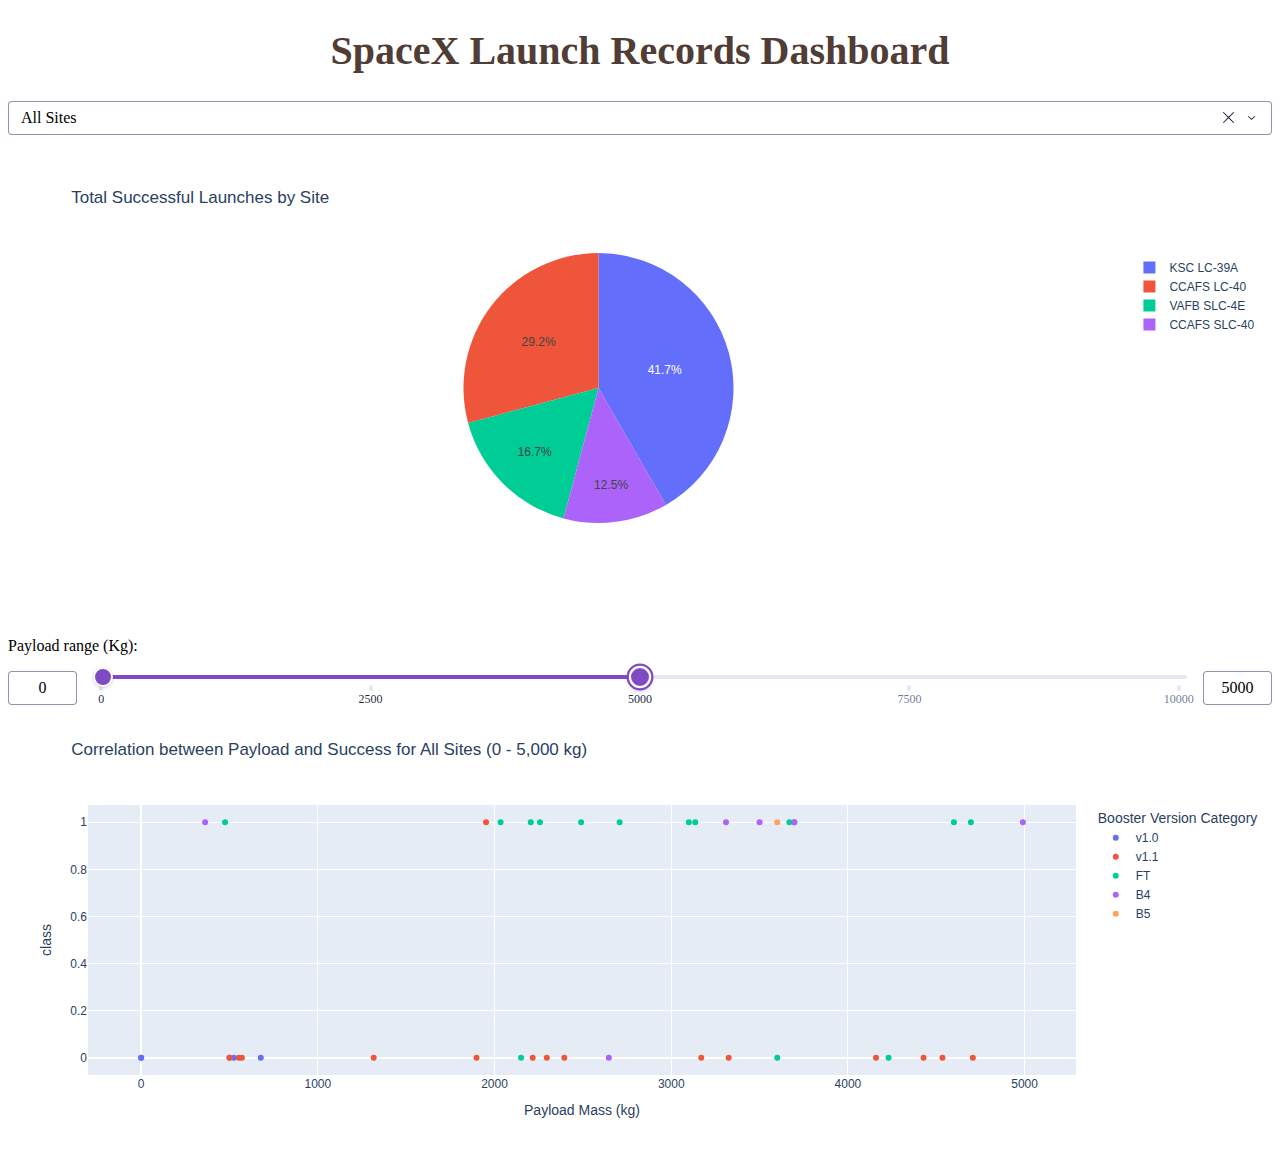

=====IMG dash_high


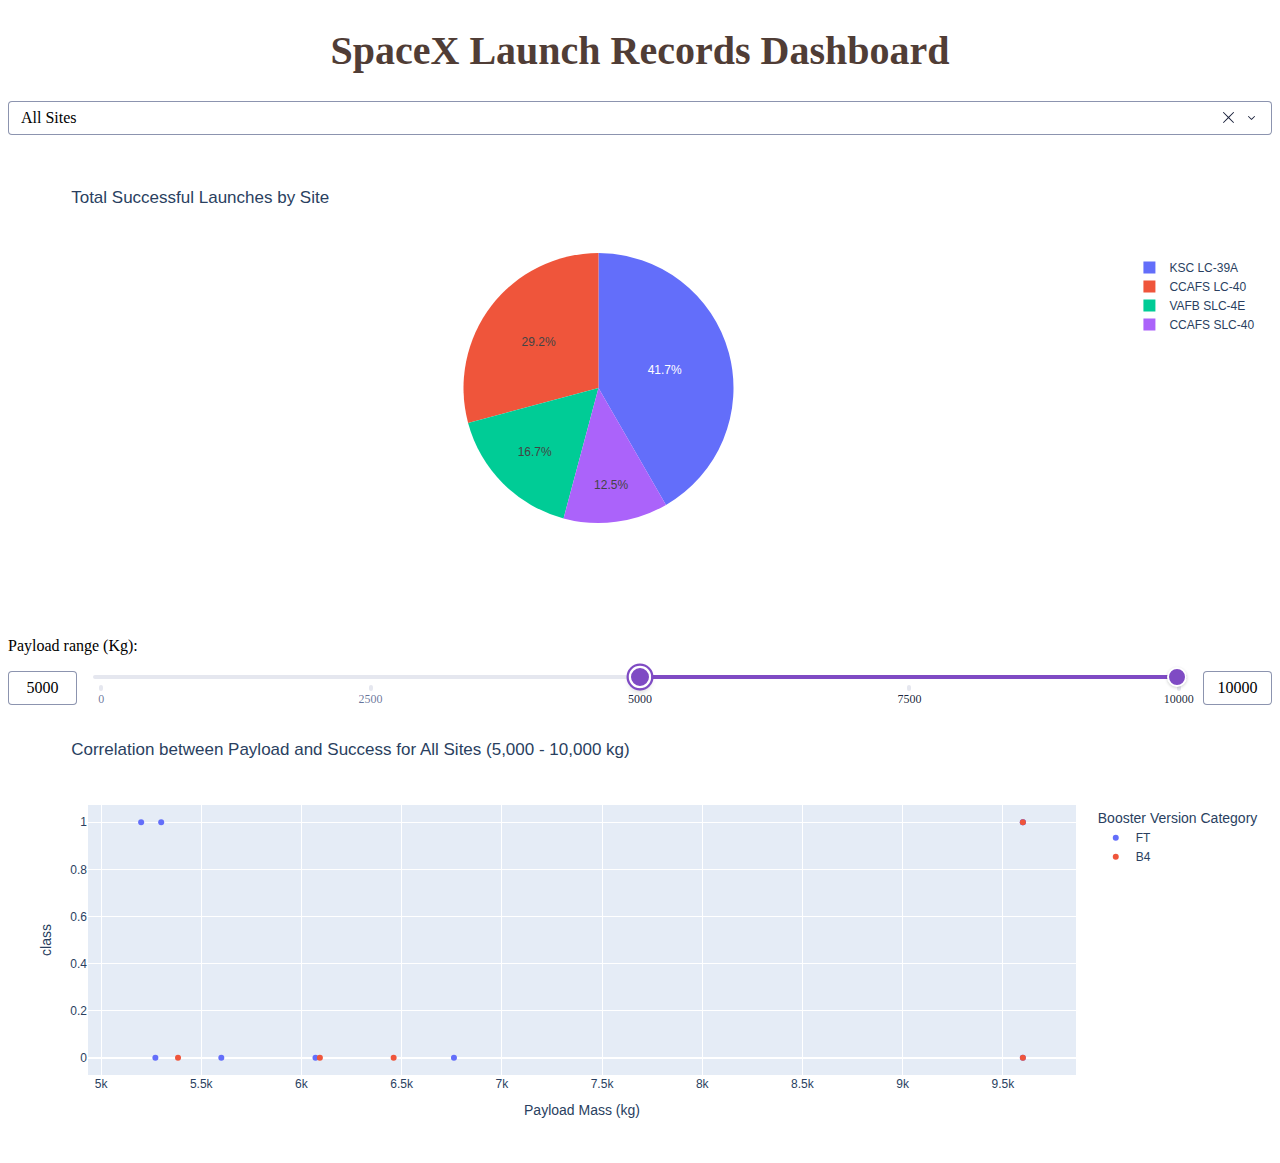

In [11]:
from IPython.display import Image, display
for s in ['map1_sites', 'map2_clusters', 'map2_ksc', 'map3_prox', 'dash_all', 'dash_ksc', 'dash_low', 'dash_high']:
    print('=====IMG', s)
    try:
        display(Image(s + '.png'))
    except Exception as e:
        print('missing', s, e)